Udacity Pytorch project 2: CIFAR-10 Image Classification

Some of the benchmark results on CIFAR-10 include:

 

78.9% Accuracy | [Deep Belief Networks; Krizhevsky, 2010](https://www.cs.toronto.edu/~kriz/conv-cifar10-aug2010.pdf)

 

90.6% Accuracy | [Maxout Networks; Goodfellow et al., 2013](https://arxiv.org/pdf/1302.4389.pdf)

 

96.0% Accuracy | [Wide Residual Networks; Zagoruyko et al., 2016](https://arxiv.org/pdf/1605.07146.pdf)

 

99.0% Accuracy | [GPipe; Huang et al., 2018](https://arxiv.org/pdf/1811.06965.pdf)

 

98.5% Accuracy | [Rethinking Recurrent Neural Networks and other Improvements for ImageClassification; Nguyen et al., 2020](https://arxiv.org/pdf/2007.15161.pdf)

In [1]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transform
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets

Load the Dataset

Specific your transforms as a list first. The transforms module is already loaded as transforms
CIFAR-10 is fortunately included in the torchvision module. Then you can create your dataset using the CIFAR10 object from torchvision.datasets. Make sure to specify download=True. 
Once your dataset is created, you'll also need to define a Dataloader from the torch.utils.data module for both train and test set



In [2]:
#Define transforms

# TODO: Define transforms for the training data and testing data
#these transforms are tentative!! Putting something in to get the ball rolling. They may very well suck. 
train_transforms = transform.Compose([transform.RandomRotation(30),
                                       transform.RandomResizedCrop(224),
                                       transform.RandomHorizontalFlip(),
                                       transform.ToTensor()]) 

test_transforms =  transform.Compose([transform.Resize(255),
                                      transform.CenterCrop(224),
                                      transform.ToTensor()])


# TODO: Define transforms for the training data and testing data
train_view_transforms = transform.Compose([transform.ToTensor()]) 

test_view_transforms =  transform.Compose([ transform.ToTensor()])


#Create training set and define training data loader
trainset = datasets.CIFAR10('data/', download=True, train=True, transform=train_transforms)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)



#Create your test set and define test data loader
testset = datasets.CIFAR10('data/', download=True, train=False, transform=test_transforms)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=True)



#the 10 classes in the dataset
classes=('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')


Files already downloaded and verified
Files already downloaded and verified


Explore the Dataset

Using matplotlib, numpy and torch, explore the dimensions of your data 

you can view images using the show5 function below - it takes a dataloader as an argument. Remember that normalized images will look really weird to you. You may want to try changing your transforms to view images.Typically using no transforms other than toTensor() works well for viewing - but not as well for training your network. If show5 doesn't work, go back and check your code for creating your dataloaders and your training/test sets.


In [3]:
def show5(img_loader):
    dataiter=iter(img_loader)

    batch=next(dataiter)
    labels=batch[1][0:5]
    image=batch[0][0:5]
    for i in range(5):
        print(classes[labels[i]])
        image=images[i].numpy()
        plt.imshow(image.T)
        plt.show()
    

Files already downloaded and verified
plane


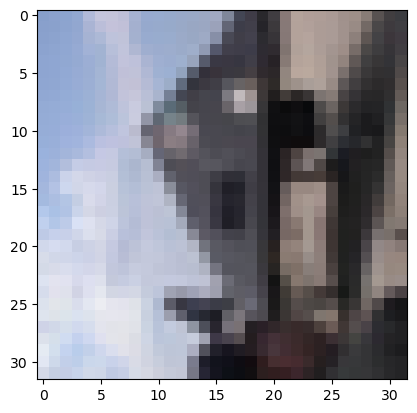

dog


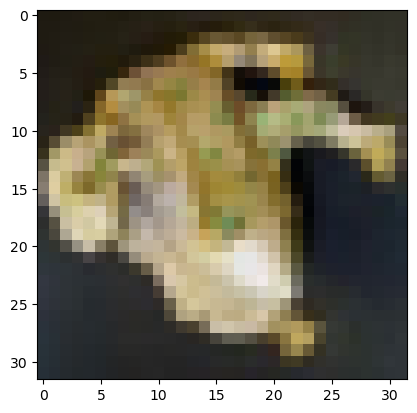

truck


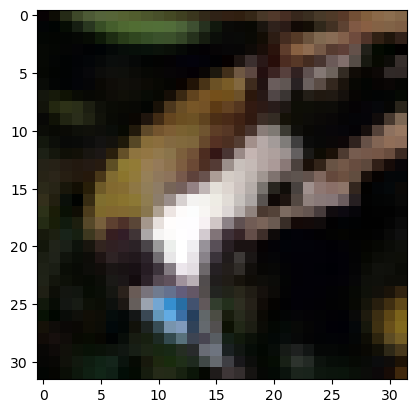

frog


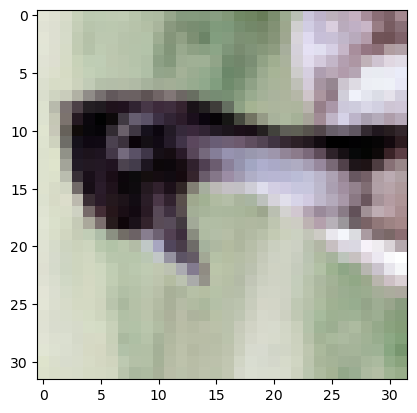

bird


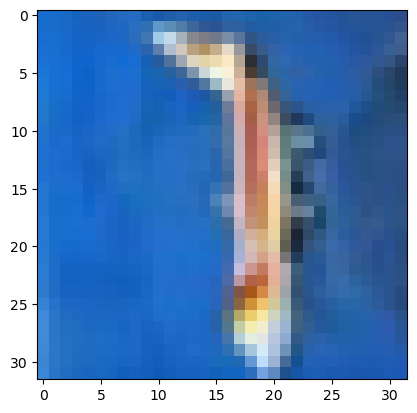

In [4]:

trainviewset = datasets.CIFAR10('data/', download=True, train=True, transform=train_view_transforms)
trainviewloader = torch.utils.data.DataLoader(trainviewset, batch_size=64, shuffle=True)

# dataiter=iter(trainviewloader)
# batch=next(dataiter)
# labels=batch[1][0:5]
# image=batch[0][0:5]
# for i in range(5):
#     print(classes[labels[i]])
#     image=images[i].numpy()
#     plt.imshow(image.T)
#     plt.show()

# Run this to test your data loader
images, labels = next(iter(trainviewloader))
#helper.imshow(images[0], normalize=False)    

dataiter=iter(trainviewloader)
batch=next(dataiter)
labels=batch[1][0:5]
image=batch[0][0:5]
for i in range(5):
    print(classes[labels[i]])
    image=images[i].numpy()
    plt.imshow(image.T)
    plt.show()


ship


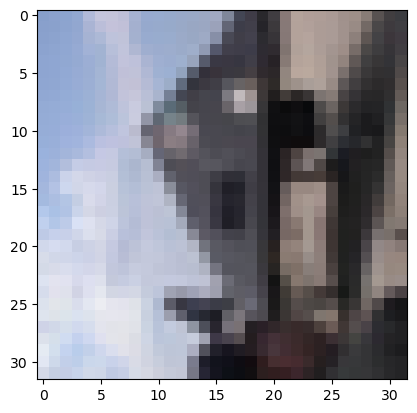

deer


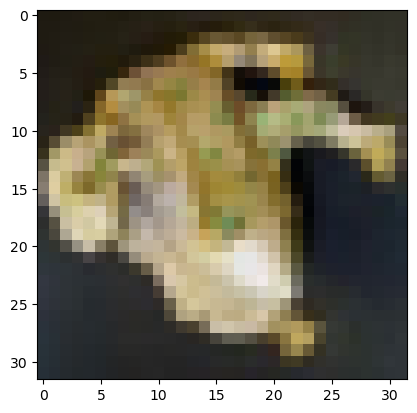

deer


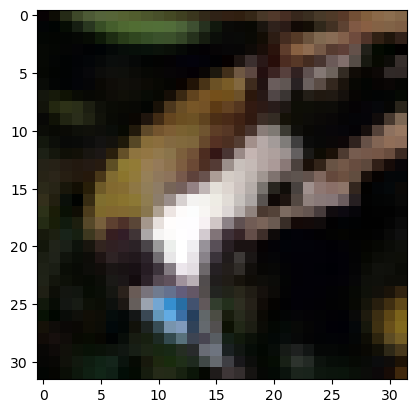

frog


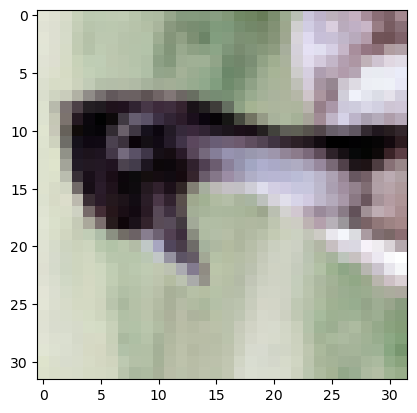

bird


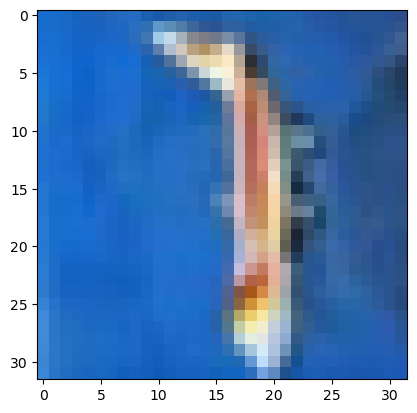

In [5]:
#explore data
image, label = next(iter(trainviewloader))
#image.shape
#print(image[0][0].shape)
show5(trainloader)


Build your Neural Network

Using the layers in torch.nn (which has been imported as nn) and the torch.nn.Functional module (imported as F)
construct a neural network based on the parameters of the dataset. Feel free to consult a model of any architecture-feedforward, convolutional or even something more advanced.

In [8]:
#do more exploring... need to get proper shape before building the network. 
dataiter = iter(trainloader)
images, labels = next(dataiter)
print(type(images))
print(images.shape)
print(labels.shape)

<class 'torch.Tensor'>
torch.Size([64, 3, 224, 224])
torch.Size([64])


In [9]:
#code here to build the network 
#placeholder model. no commitment to keep this. again, this won't work as the shape does not fit the cifar10 data

class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 10)
        
    def forward(self, x):
        # make sure input tensor is flattened
        x = x.view(x.shape[0], -1)
        
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.log_softmax(self.fc4(x), dim=1)
        
        return x

Specify a loss function and an optimizer and instantiate the model.
if you use a less common loss function, please note why you chose that function in a comment. 

In [10]:
#code for loss fx and optimizer here
model = Classifier()
#placeholder loss function and optimizer
criterion = nn.NLLLoss(reduction='sum')
optimizer = optim.Adam(model.parameters(), lr=0.003)


Running your Neural Network 

use whatever method you like to train your neural network and ensure you record the average loss at each epoch. Don't forget to use torch.device() and the .to() method for both your model and data if you are using GPU

if you want to print your loss during each epoch, you can use the enumerate function and print the loss after a set of batches. 250 batches works well for most people. 

In [11]:
#code to run the network 

#placeholder training/testing 

#pull from the right loader
image, label = next(iter(trainloader))

#one epoch to start just to work out the kinks, if any
epochs = 1

train_losses, test_losses = [], []
for e in range(epochs):
    tot_train_loss = 0
    model.train()
    for images, labels in trainloader:
        optimizer.zero_grad()
        
        log_ps = model(images)
        loss = criterion(log_ps, labels)
        tot_train_loss += loss.item()
        
        loss.backward()
        optimizer.step()
    else:
        tot_test_loss = 0
        test_correct = 0  # Number of correct predictions on the test set
        
        # Turn off gradients for validation, saves memory and computations
        with torch.no_grad():
            model.eval()
            for images, labels in testloader:
                log_ps = model(images)
                loss = criterion(log_ps, labels)
                tot_test_loss += loss.item()

                ps = torch.exp(log_ps)
                top_p, top_class = ps.topk(1, dim=1)
                equals = top_class == labels.view(*top_class.shape)
                test_correct += equals.sum().item()

        # Get mean loss to enable comparison between train and test sets
        train_loss = tot_train_loss / len(trainloader.dataset)
        test_loss = tot_test_loss / len(testloader.dataset)

        # At completion of epoch
        train_losses.append(train_loss)
        test_losses.append(test_loss)

        print("Epoch: {}/{}.. ".format(e+1, epochs),
              "Training Loss: {:.3f}.. ".format(train_loss),
              "Test Loss: {:.3f}.. ".format(test_loss),
              "Test Accuracy: {:.3f}".format(test_correct / len(testloader.dataset)))


RuntimeError: mat1 and mat2 shapes cannot be multiplied (64x150528 and 784x256)

Plot the training loss (and validation loss/accuracy, if recorded)

In [10]:
#showing the plots 

Testing your model 

using the previously created DataLoader for the test set, compute the percentage of correct predictions using the highest probability prediction. 

If your accuracy is under 45% you'll need to make improvements. Go back and check your model architecture, loss function, and optimizer to make sure they are appropriate for an image classification task. 

In [11]:
#code to test the model 

Saving your model 

using torch.save, save your model for future loading

In [12]:
#code to save the model 

Make a recommendation

Based on your evaluation, what is your recommendation on whether to build or buy? Explain your reasoning below. 

In [13]:
#put your explanation here. 